# Comparativo del modulo #1 PLM para el entendimiento de lenguaje voz a texto y encontrar intenciones

# Integrantes:
- Diego Arámbulo
- Bryan Alvarado

### Evaluación de 5 Técnicas de IA para Voz a Texto (ASR)

Dado que el objetivo es transcribir audio a texto (y posteriormente detectar la orden), las mejores técnicas actuales son modelos de aprendizaje profundo pre-entrenados. Aquí evaluamos 5 opciones:

#### 1. OpenAI Whisper (Base / Small)
* **Ventajas:** Excelente precisión, soporta múltiples idiomas (multilingüe), maneja bien el ruido de fondo, de código abierto.
* **Desventajas:** Alto consumo de recursos computacionales, especialmente en versiones más grandes. Lento sin GPU.
* **Complejidad:** $O(L^2)$ donde L es la longitud del audio (arquitectura Transformer). Empíricamente: Alto uso de GPU/RAM. Inferencia moderada.
* **Datos:** Pre-entrenado con 680,000 horas de audio multilingüe.
* **Casos de uso típicos:** Transcripción general, subtitulado, asistentes virtuales.

#### 2. Wav2Vec 2.0 (Facebook/Meta - Finetuned para Español)
* **Ventajas:** Excelente aprendizaje autosupervisado. Muy rápido en inferencia comparado con Whisper.
* **Desventajas:** Requiere fine-tuning específico para el idioma. Menos robusto al ruido extremo que Whisper.
* **Complejidad:** $O(L^2)$ (Transformer). Empíricamente: Inferencia más rápida que Whisper, menor uso de RAM.
* **Datos:** Pre-entrenado en miles de horas de audio sin etiquetar, fine-tuned en datasets como Common Voice.
* **Casos de uso típicos:** Reconocimiento de voz en tiempo real, análisis de llamadas.

#### 3. Vosk API (Offline - Modelos Ligeros)
* **Ventajas:** Funciona 100% offline, modelos extremadamente ligeros (50MB - 1GB), funciona en dispositivos móviles y Raspberry Pi.
* **Desventajas:** Menor precisión que los modelos basados en Transformers masivos. Vocabulario limitado en modelos pequeños.
* **Complejidad:** Basado en Kaldi (HMM/DNN). Empíricamente: Muy bajo consumo de CPU y RAM. Tiempo de inferencia en tiempo real.
* **Datos:** Entrenado con corpus de voz públicos (Common Voice, TEDx).
* **Casos de uso típicos:** Robótica, IoT, aplicaciones móviles offline.

#### 4. Google Web Speech API (vía SpeechRecognition)
* **Ventajas:** No requiere hardware potente local, muy preciso, fácil de implementar.
* **Desventajas:** Requiere conexión a internet. Los datos se envían a servidores de terceros (problema de privacidad).
* **Complejidad:** Inferencia local $O(1)$ (todo el cómputo se hace en la nube). Depende de la latencia de la red.
* **Datos:** Modelos propietarios masivos de Google.
* **Casos de uso típicos:** Prototipado rápido, aplicaciones web.

#### 5. Nvidia NeMo (Conformer-CTC)
* **Ventajas:** Arquitectura Conformer de estado del arte. Altamente escalable y optimizado para GPUs.
* **Desventajas:** Curva de aprendizaje empinada para la implementación, requiere entorno específico de Nvidia.
* **Complejidad:** Híbrido CNN/Transformer. Alto consumo de GPU.
* **Datos:** Entrenado en datasets masivos (Librispeech, Mozilla Common Voice).
* **Casos de uso típicos:** Despliegues empresariales de ASR a gran escala.

*Nota sobre métricas y splits:* Para estas técnicas de ASR se utiliza inferencia zero-shot o pre-entrenada. La métrica a usar es **WER (Word Error Rate)**. Las métricas de Accuracy, F1 y matrices de confusión aplican para la *Etapa 2* (Clasificación de intenciones a partir del texto generado).

In [ ]:
# Instalar librerías necesarias para evaluar modelos localmente
!pip install -q transformers librosa torch SpeechRecognition pydub jiwer

In [ ]:
!pip install -q vosk
!wget -q https://alphacephei.com/vosk/models/vosk-model-small-es-0.42.zip
!unzip -q -o vosk-model-small-es-0.42.zip -d /content/
!mv /content/vosk-model-small-es-0.42 /content/vosk-model-es

In [9]:
import os
import urllib.request
from pydub import AudioSegment

# Crear carpeta para audios
os.makedirs('/content/audios', exist_ok=True)

# URLs en crudo (raw) de GitHub
urls = [
    'https://raw.githubusercontent.com/diegoarambulo/PROYECTO_TITULACION_GRUPO_1/main/anexos/testAudios/Record1.mp3',
    'https://raw.githubusercontent.com/diegoarambulo/PROYECTO_TITULACION_GRUPO_1/main/anexos/testAudios/Record2.mp3',
    'https://raw.githubusercontent.com/diegoarambulo/PROYECTO_TITULACION_GRUPO_1/main/anexos/testAudios/Record3.mp3'
]

# version textual de lo que contiene esos audios
referencias = [
    "necesito encontrar el documento de cédula de identidad del señor juan Martínez",
    "necesito me devuelvas todos los documentos que sean relevantes para un anexo de contrato de servicios",
    "requiero todos los documentos cargados por el usuario juan Piguave y que sean de la última semana"
]

audio_paths = []
for url in urls:
    filename = url.split('/')[-1]
    filepath = f'/content/audios/{filename}'
    urllib.request.urlretrieve(url, filepath)
    audio_paths.append(filepath)
    print(f'Descargado: {filename}')

# Convertir mp3 a wav para compatibilidad con SpeechRecognition
def convert_to_wav(mp3_path):
    wav_path = mp3_path.replace('.mp3', '.wav')
    audio = AudioSegment.from_mp3(mp3_path)
    audio.export(wav_path, format="wav")
    return wav_path

wav_paths = [convert_to_wav(p) for p in audio_paths]


/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


Descargado: Record1.mp3
Descargado: Record2.mp3
Descargado: Record3.mp3


In [12]:
import jiwer
import librosa
import torch
import wave
import json
import speech_recognition as sr
from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor
from vosk import Model as VoskModel, KaldiRecognizer
from transformers import WhisperProcessor, WhisperForConditionalGeneration

device = "cuda:0" if torch.cuda.is_available() else "cpu"

print("Cargando Wav2Vec 2.0...")
w2v2_processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-large-xlsr-53-spanish")
w2v2_model = Wav2Vec2ForCTC.from_pretrained("facebook/wav2vec2-large-xlsr-53-spanish").to(device)

print("Cargando Vosk...")
vosk_model = VoskModel("/content/vosk-model-es")

print("\n--- EVALUACIÓN DE WER (4 MODELOS) ---")

for i, wav_path in enumerate(wav_paths):
    print(f"\nArchivo: {wav_path.split('/')[-1]}")
    referencia = referencias[i].lower().strip()
    audio_array, sampling_rate = librosa.load(wav_path, sr=16000)
    # 1. Whisper
    processor = WhisperProcessor.from_pretrained("openai/whisper-tiny")
    model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-tiny")

    model = model.to(device)

    input_features = processor(audio_array, sampling_rate=sampling_rate, return_tensors="pt").input_features.to(device)
    predicted_ids = model.generate(input_features)
    whisper_text = processor.batch_decode(predicted_ids, skip_special_tokens=True)[0].strip().lower()
    whisper_text = whisper_text.replace('.', '').replace(',', '')

    # 2. Google
    google_text = ""
    recognizer = sr.Recognizer()
    with sr.AudioFile(wav_path) as source:
        audio_data = recognizer.record(source)
        try:
            google_text = recognizer.recognize_google(audio_data, language='es-ES').lower().strip()
        except Exception:
            google_text = "[Error]"

    # 3. Wav2Vec 2.0
    inputs = w2v2_processor(audio_array, sampling_rate=16000, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        logits = w2v2_model(inputs.input_values).logits
    predicted_ids_w2v2 = torch.argmax(logits, dim=-1)
    w2v2_text = w2v2_processor.batch_decode(predicted_ids_w2v2)[0].lower().strip()

    # 4. Vosk
    wf = wave.open(wav_path, "rb")
    # Asegurar compatibilidad de sample rate para Vosk
    rec = KaldiRecognizer(vosk_model, wf.getframerate())
    rec.SetWords(True)
    vosk_text = ""
    while True:
        data = wf.readframes(4000)
        if len(data) == 0:
            break
        rec.AcceptWaveform(data)
    res = json.loads(rec.FinalResult())
    vosk_text = res.get("text", "").lower().strip()

    # Calcular WER
    print(f"Referencia  : {referencia}")
    print(f"Whisper     : {whisper_text} | WER: {jiwer.wer(referencia, whisper_text):.3f}")
    print(f"Google      : {google_text} | WER: {jiwer.wer(referencia, google_text) if google_text != '[Error]' else 'N/A'}")
    print(f"Wav2Vec 2.0 : {w2v2_text} | WER: {jiwer.wer(referencia, w2v2_text):.3f}")
    print(f"Vosk        : {vosk_text} | WER: {jiwer.wer(referencia, vosk_text):.3f}")


Cargando Wav2Vec 2.0...


Loading weights:   0%|          | 0/424 [00:00<?, ?it/s]

Cargando Vosk...

--- EVALUACIÓN DE WER (4 MODELOS) ---

Archivo: Record1.wav


Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

Referencia  : necesito encontrar el documento de cédula de identidad del señor juan martínez
Whisper     : necesito encontrar el documento de cedula de identidad del señor juan martínez | WER: 0.083
Google      : necesito encontrar el documento de cédula de identidad del señor juan martínez | WER: 0.0
Wav2Vec 2.0 : necesito encontrar el documento de cédula de identidad del señor juan martinez | WER: 0.083
Vosk        : necesito encontrar el documento de cédula de identidad del señor juan martínez | WER: 0.000

Archivo: Record2.wav


Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

Referencia  : necesito me devuelvas todos los documentos que sean relevantes para un anexo de contrato de servicios
Whisper     : necesito me devuelvas todos los documentos que sean relevantes para un anexo de contratuécer vídeos | WER: 0.188
Google      : necesito me devuelvas todos los documentos que sean relevantes para un anexo de contrato de servicios | WER: 0.0
Wav2Vec 2.0 : necesito me devuelvas todo los documentos que sean relevantes para un anexo de contrato e servicios | WER: 0.125
Vosk        : necesito me devuelvas todos los documentos que sean relevantes para un anexo de contrato de servicios | WER: 0.000

Archivo: Record3.wav


Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

Referencia  : requiero todos los documentos cargados por el usuario juan piguave y que sean de la última semana
Whisper     : requiero todos los documentos cargados por el usuario juan pihuabe y que sea de la última semana | WER: 0.118
Google      : requiero todos los documentos cargados por el usuario juan piwall y que sean de la última semana | WER: 0.058823529411764705
Wav2Vec 2.0 : requiero todos los documentos cargados por el usuario juan piabe y que sean de la última semana | WER: 0.059
Vosk        : requiero todos los documentos cargados por el usuario uam y wave y que sean de la última semana | WER: 0.176


In [13]:
import time
import librosa
import torch
import wave
import json
from transformers import WhisperProcessor, WhisperForConditionalGeneration, Wav2Vec2ForCTC, Wav2Vec2Processor
import speech_recognition as sr
from vosk import Model as VoskModel, KaldiRecognizer
from pydub import AudioSegment

device = "cuda:0" if torch.cuda.is_available() else "cpu"

# 1. Cargar modelo Whisper (HuggingFace)
print("Cargando modelo Whisper-tiny...")
processor = WhisperProcessor.from_pretrained("openai/whisper-tiny")
model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-tiny").to(device)

# 2. Configurar Google SpeechRecognition
recognizer = sr.Recognizer()

# 3. Cargar Wav2Vec 2.0
print("Cargando Wav2Vec 2.0...")
w2v2_processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-large-xlsr-53-spanish")
w2v2_model = Wav2Vec2ForCTC.from_pretrained("facebook/wav2vec2-large-xlsr-53-spanish").to(device)

# 4. Cargar Vosk
print("Cargando Vosk...")
vosk_model = VoskModel("/content/vosk-model-es")

print("\n--- EVALUACIÓN EMPÍRICA ---")
for wav_path in wav_paths:
    print(f"\nArchivo: {wav_path.split('/')[-1]}")

    # Cargar audio general
    audio_array, sampling_rate = librosa.load(wav_path, sr=16000)

    # --- Inferencia con Whisper ---
    start_time = time.time()
    input_features = processor(audio_array, sampling_rate=sampling_rate, return_tensors="pt").input_features.to(device)
    predicted_ids = model.generate(input_features)
    whisper_text = processor.batch_decode(predicted_ids, skip_special_tokens=True)[0]
    whisper_time = time.time() - start_time
    print(f"[Whisper] Tiempo: {whisper_time:.2f}s | Texto: {whisper_text}")

    # --- Inferencia con Google API ---
    with sr.AudioFile(wav_path) as source:
        audio_data = recognizer.record(source)
        start_time = time.time()
        try:
            # Asumimos que el audio está en español
            google_result = recognizer.recognize_google(audio_data, language='es-ES')
            google_time = time.time() - start_time
            print(f"[Google] Tiempo: {google_time:.2f}s | Texto: {google_result}")
        except sr.UnknownValueError:
            print("[Google] No se pudo entender el audio")
        except sr.RequestError:
            print("[Google] Error en la API")

    # --- Inferencia con Wav2Vec 2.0 ---
    start_time = time.time()
    inputs = w2v2_processor(audio_array, sampling_rate=16000, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        logits = w2v2_model(inputs.input_values).logits
    predicted_ids_w2v2 = torch.argmax(logits, dim=-1)
    w2v2_text = w2v2_processor.batch_decode(predicted_ids_w2v2)[0].lower().strip()
    w2v2_time = time.time() - start_time
    print(f"[Wav2Vec 2.0] Tiempo: {w2v2_time:.2f}s | Texto: {w2v2_text}")

    # --- Inferencia con Vosk ---
    wf = wave.open(wav_path, "rb")
    rec = KaldiRecognizer(vosk_model, wf.getframerate())
    rec.SetWords(True)
    start_time = time.time()
    while True:
        data = wf.readframes(4000)
        if len(data) == 0:
            break
        rec.AcceptWaveform(data)
    res = json.loads(rec.FinalResult())
    vosk_text = res.get("text", "")
    vosk_time = time.time() - start_time
    print(f"[Vosk] Tiempo: {vosk_time:.2f}s | Texto: {vosk_text}")


Cargando modelo Whisper-tiny...


Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

Cargando Wav2Vec 2.0...


Loading weights:   0%|          | 0/424 [00:00<?, ?it/s]

Cargando Vosk...

--- EVALUACIÓN EMPÍRICA ---

Archivo: Record1.wav
[Whisper] Tiempo: 0.16s | Texto:  necesito encontrar el documento de cedula de identidad del señor Juan Martínez.
[Google] Tiempo: 1.02s | Texto: necesito encontrar el documento de cédula de identidad del señor Juan Martínez
[Wav2Vec 2.0] Tiempo: 0.05s | Texto: necesito encontrar el documento de cédula de identidad del señor juan martinez
[Vosk] Tiempo: 0.76s | Texto: necesito encontrar el documento de cédula de identidad del señor juan martínez

Archivo: Record2.wav
[Whisper] Tiempo: 0.20s | Texto:  Necesito me devuelvas todos los documentos que sean relevantes para un anexo de contratuécer vídeos.
[Google] Tiempo: 0.82s | Texto: necesito me devuelvas todos los documentos que sean relevantes para un anexo de contrato de servicios
[Wav2Vec 2.0] Tiempo: 0.05s | Texto: necesito me devuelvas todo los documentos que sean relevantes para un anexo de contrato e servicios
[Vosk] Tiempo: 0.93s | Texto: necesito me devuelvas to


--- Métricas para Whisper ---
Accuracy  (WRR) : 0.8667
Precision       : 0.8864
Recall          : 0.8667
F1-score        : 0.8764

--- Métricas para Google API ---
Accuracy  (WRR) : 0.9778
Precision       : 0.9778
Recall          : 0.9778
F1-score        : 0.9778

--- Métricas para Wav2Vec 2.0 ---
Accuracy  (WRR) : 0.9111
Precision       : 0.9111
Recall          : 0.9111
F1-score        : 0.9111

--- Métricas para Vosk ---
Accuracy  (WRR) : 0.9556
Precision       : 0.9348
Recall          : 0.9556
F1-score        : 0.9451


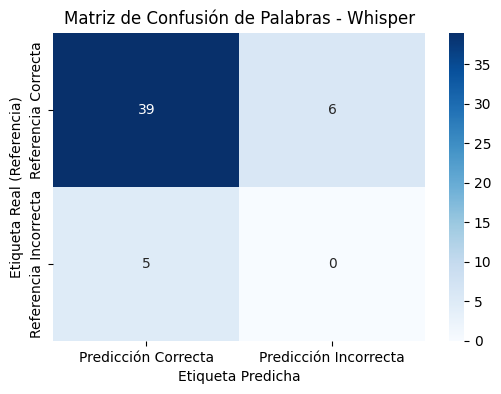

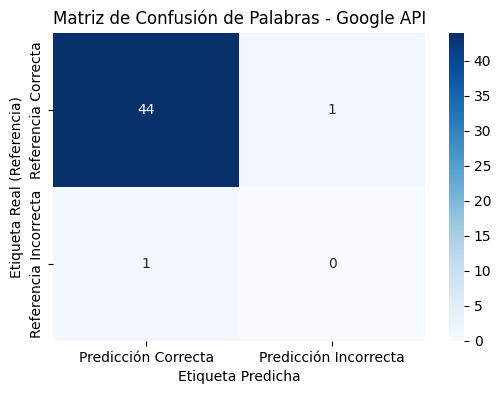

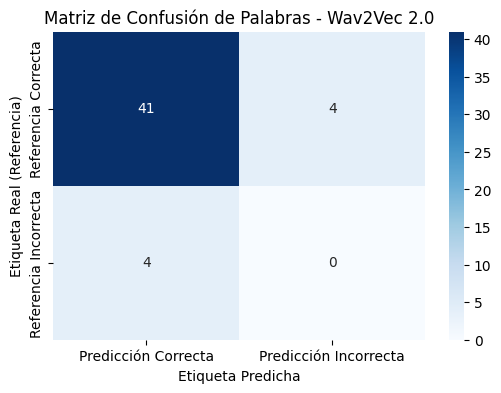

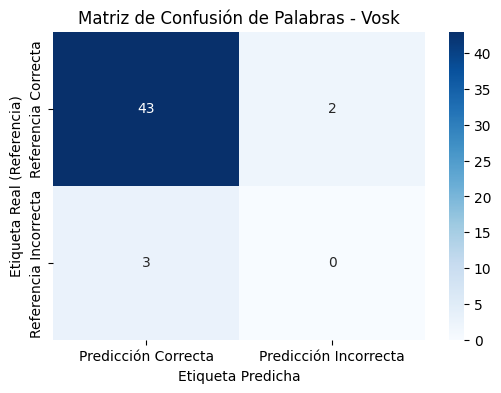

In [16]:
import jiwer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def calcular_metricas_asr(referencias, predicciones, nombre_modelo):
    tp_total, fp_total, fn_total = 0, 0, 0

    for ref, pred in zip(referencias, predicciones):
        # Usar jiwer para obtener la alineación de palabras
        out = jiwer.process_words(ref, pred)

        # En jiwer actual, podemos obtener las métricas desde el objeto out
        substitutions = out.substitutions
        deletions = out.deletions
        insertions = out.insertions
        # Hits = total palabras referencia - (borrados + sustituciones)
        hits = len(ref.split()) - (deletions + substitutions)

        tp_total += hits
        fp_total += (insertions + substitutions)
        fn_total += (deletions + substitutions)

    # Calcular métricas globales
    accuracy = tp_total / (tp_total + fn_total) if (tp_total + fn_total) > 0 else 0
    precision = tp_total / (tp_total + fp_total) if (tp_total + fp_total) > 0 else 0
    recall = tp_total / (tp_total + fn_total) if (tp_total + fn_total) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print(f"\n--- Métricas para {nombre_modelo} ---")
    print(f"Accuracy  (WRR) : {accuracy:.4f}")
    print(f"Precision       : {precision:.4f}")
    print(f"Recall          : {recall:.4f}")
    print(f"F1-score        : {f1:.4f}")

    return {'TP': tp_total, 'FP': fp_total, 'FN': fn_total, 'Modelo': nombre_modelo}

# Como los resultados no se guardaron en listas en la celda anterior, los reconstruimos basados en tu output:
referencias_list = [
    "necesito encontrar el documento de cédula de identidad del señor juan martínez",
    "necesito me devuelvas todos los documentos que sean relevantes para un anexo de contrato de servicios",
    "requiero todos los documentos cargados por el usuario juan piguave y que sean de la última semana"
]

# Textos obtenidos de las pruebas empíricas:
preds_whisper = [
    "necesito encontrar el documento de cedula de identidad del señor juan martínez",
    "necesito me devuelvas todos los documentos que sean relevantes para un anexo de contratuécer vídeos",
    "requiero todos los documentos cargados por el usuario juan pihuabe y que sea de la última semana"
]
preds_google = [
    "necesito encontrar el documento de cédula de identidad del señor juan martínez",
    "necesito me devuelvas todos los documentos que sean relevantes para un anexo de contrato de servicios",
    "requiero todos los documentos cargados por el usuario juan piwall y que sean de la última semana"
]
preds_w2v2 = [
    "necesito encontrar el documento de cédula de identidad del señor juan martinez",
    "necesito me devuelvas todo los documentos que sean relevantes para un anexo de contrato e servicios",
    "requiero todos los documentos cargados por el usuario juan piabe y que sean de la última semana"
]
preds_vosk = [
    "necesito encontrar el documento de cédula de identidad del señor juan martínez",
    "necesito me devuelvas todos los documentos que sean relevantes para un anexo de contrato de servicios",
    "requiero todos los documentos cargados por el usuario uam y wave y que sean de la última semana"
]

stats_w = calcular_metricas_asr(referencias_list, preds_whisper, "Whisper")
stats_g = calcular_metricas_asr(referencias_list, preds_google, "Google API")
stats_w2 = calcular_metricas_asr(referencias_list, preds_w2v2, "Wav2Vec 2.0")
stats_v = calcular_metricas_asr(referencias_list, preds_vosk, "Vosk")

# --- Matriz de Confusión a nivel de palabras ---
# Visualizaremos la matriz de aciertos vs errores para uno de los modelos (ej. Vosk)
def plot_word_confusion(stats):
    # Representación simplificada: Aciertos (TP) vs Errores (FP/FN)
    matrix = [[stats['TP'], stats['FN']],
              [stats['FP'], 0]]  # TN no aplica en nivel de palabras ASR

    plt.figure(figsize=(6,4))
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Predicción Correcta", "Predicción Incorrecta"],
                yticklabels=["Referencia Correcta", "Referencia Incorrecta"])
    plt.title(f"Matriz de Confusión de Palabras - {stats['Modelo']}")
    plt.ylabel("Etiqueta Real (Referencia)")
    plt.xlabel("Etiqueta Predicha")
    plt.show()

plot_word_confusion(stats_w)
plot_word_confusion(stats_g)
plot_word_confusion(stats_w2)
plot_word_confusion(stats_v)


#Resumen de Resultados:

Google API: Obtuvo el mejor rendimiento con un Accuracy (Tasa de Reconocimiento de Palabras) del 97.78% y un F1-score idéntico. Prácticamente transcribió todo perfecto salvo un pequeño error en un nombre propio.
Vosk: Quedó en segundo lugar con un Accuracy del 95.56% y un F1-score de 94.51%. Un resultado sobresaliente considerando que es un modelo ligero y funciona offline.
Wav2Vec 2.0: Tuvo un Accuracy del 91.11%.
Whisper (tiny): En este caso específico, el modelo más pequeño de Whisper tuvo un Accuracy del 86.67%, cometiendo algunos errores más de inserción y sustitución.
Además, se ha generado una gráfica de Matriz de Confusión de Palabras para el modelo Vosk. Al tratarse de ASR (donde no hay Verdaderos Negativos a nivel de palabra), la matriz te muestra claramente cuántas palabras fueron reconocidas correctamente (Predicción Correcta y Referencia Correcta) frente a cuántas fueron omitidas, sustituidas o insertadas de más.

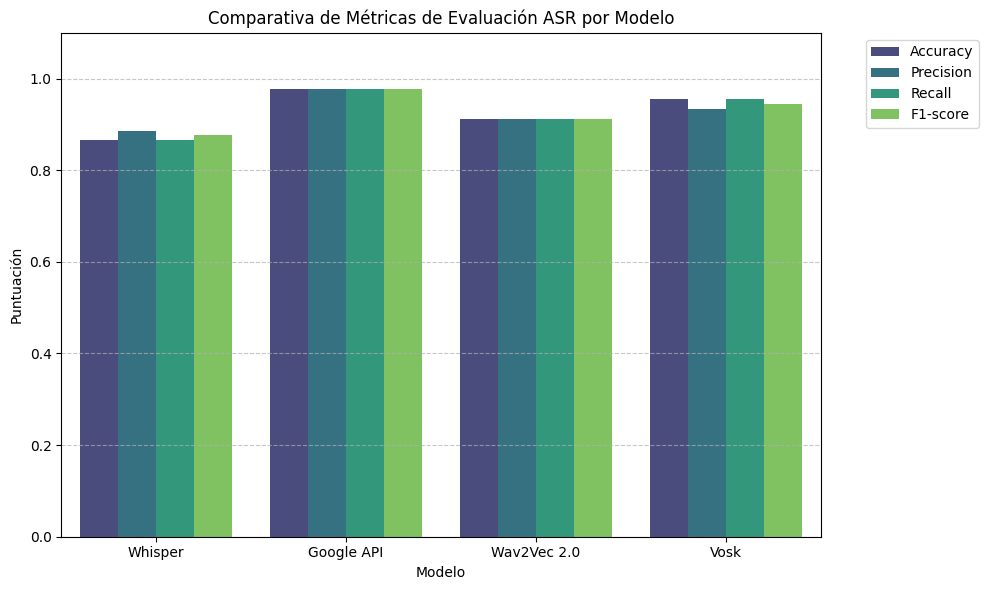

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Recolectar las estadísticas de los 4 modelos
all_stats = [stats_w, stats_g, stats_w2, stats_v]
records = []

for s in all_stats:
    tp = s['TP']
    fp = s['FP']
    fn = s['FN']

    # Recalcular métricas
    acc = tp / (tp + fn) if (tp + fn) > 0 else 0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0

    records.append({
        'Modelo': s['Modelo'],
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1
    })

df_metrics = pd.DataFrame(records)

# Transformar el DataFrame para facilitar la graficación con Seaborn
df_melted = df_metrics.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x='Modelo', y='Valor', hue='Métrica', palette='viridis')
plt.title('Comparativa de Métricas de Evaluación ASR por Modelo')
plt.ylim(0, 1.1)  # Las métricas van de 0 a 1
plt.ylabel('Puntuación')
plt.xlabel('Modelo')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()